<a href="https://colab.research.google.com/github/ehsankarami1358/LOKA_HYDRO/blob/main/U3_Temperature_Analysis_2026_R3_Dynamic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Electrical columns:
['Timestamp', 'Active_power(MW)', 'Reactive_power(Mvar)', 'UNIT Voltage_AB(kV)', 'UNIT Voltage_BC(kV)', 'UNIT Voltage_CA(kV)', 'UNIT CURRENT PHASE A', 'UNIT CURRENT PHASE B', 'UNIT CURRENT PHASE C', 'FIELD CURRENT', 'FIELD VOLTAGE']

Temperature columns:
['Timestamp', 'STATOR WINDING PHASE U2 TEMP', 'STATOR WINDING PHASE U164 TEMP', 'GENERATOR COOLING WATER INLET TEMP', 'UPPER BEARING OIL COOLER WARM WATER', 'LOWER BEARING OIL COOLER WARM WATER', 'UPPER GUIDE BEARING PAD TEMP', 'LOWER GUIDE BEARING PAD TEMP', 'COLD AIR TEMP', 'HOT AIR TEMP', 'GENERATOR COOLING WATER OUTLET TEMP']

Merged shape: (1000, 21)

Rows before steady filter: 1000
Rows after steady filter : 592


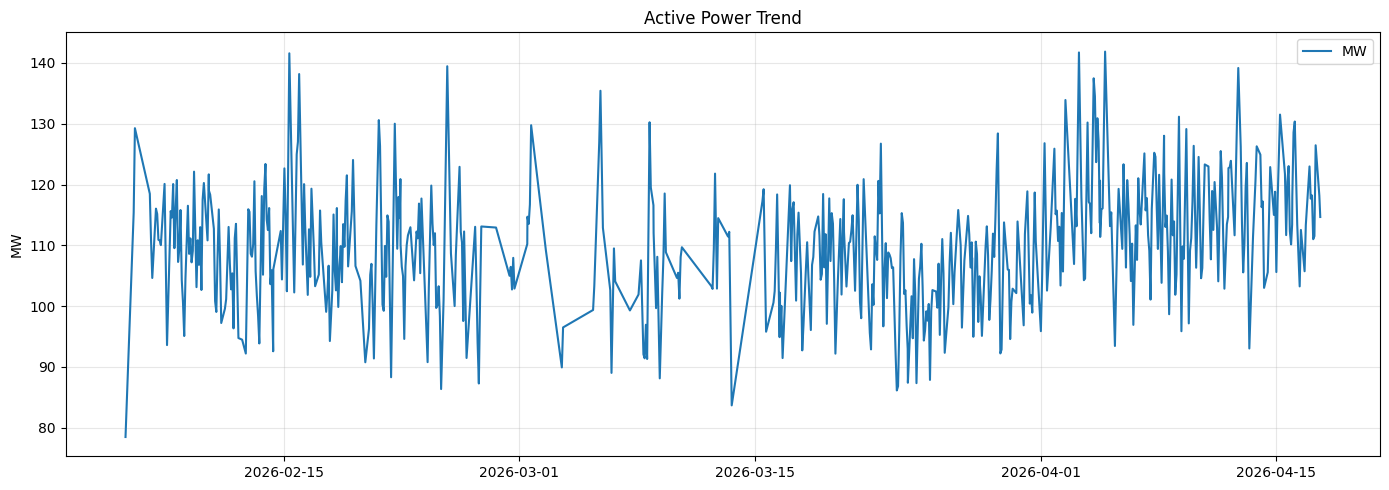

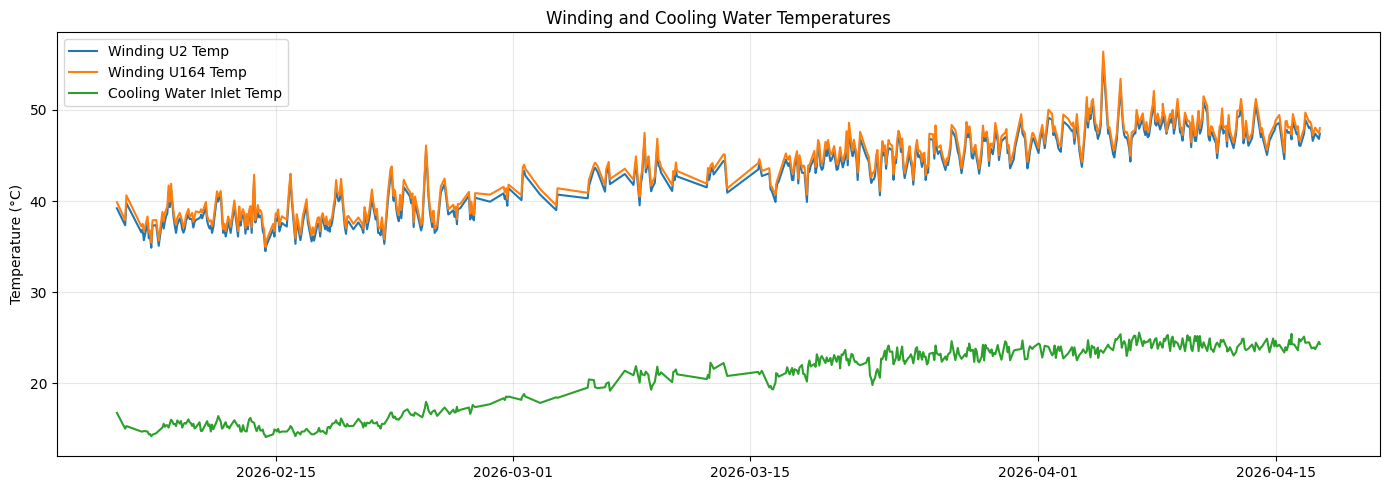

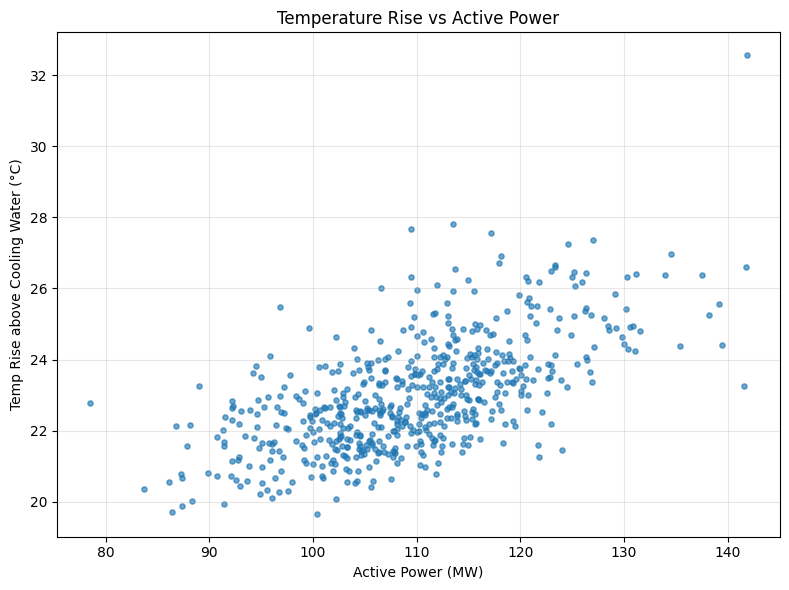

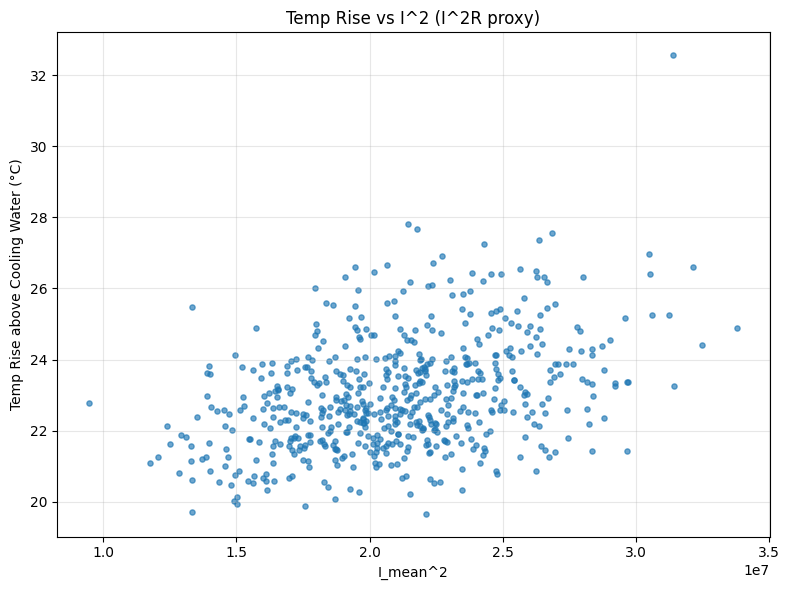

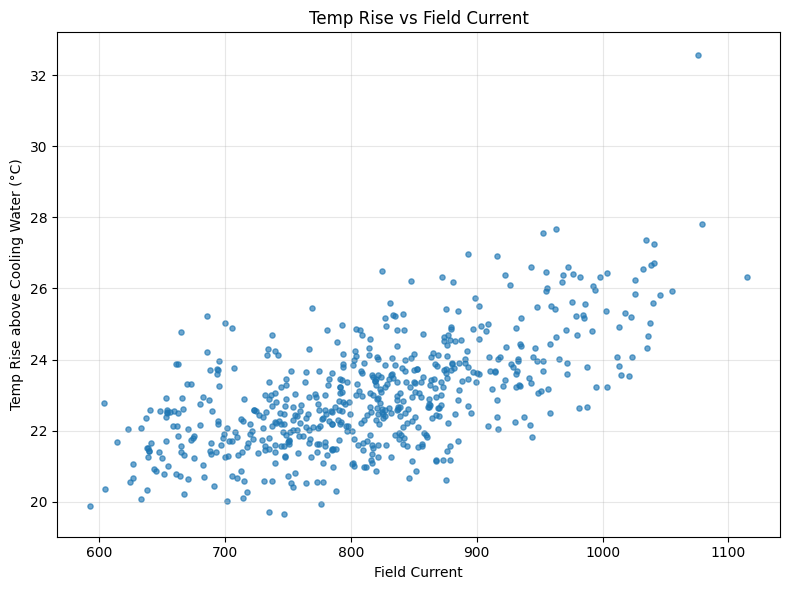

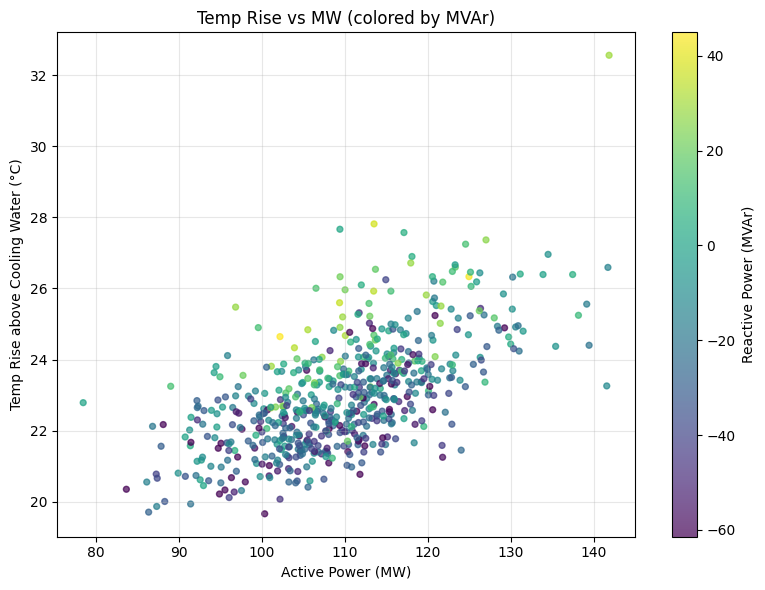

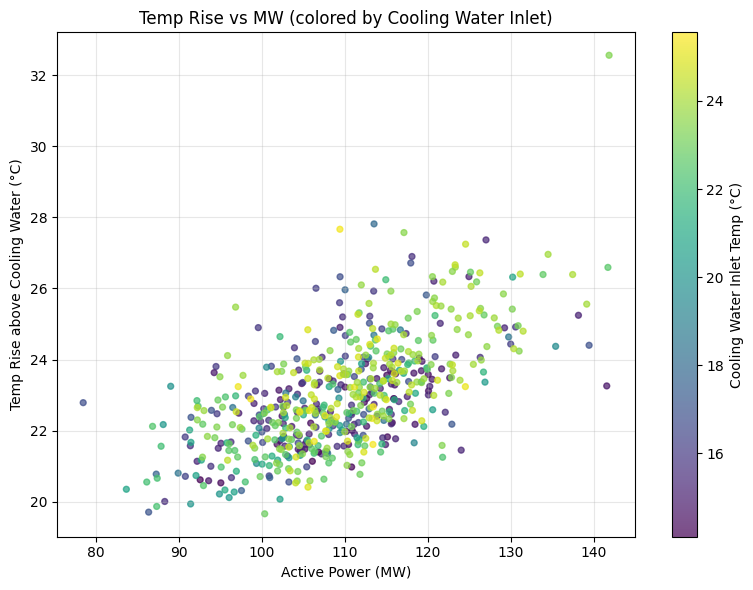


===== DYNAMIC MODEL PERFORMANCE =====
              Model  Train_R2  Test_R2  Train_MAE_C  Test_MAE_C  Train_RMSE_C  \
0  LinearRegression    0.6821   0.5148       0.6959      0.7558        0.8725   
1      RandomForest    0.8489   0.4921       0.4268      0.7832        0.6014   
2           XGBoost    0.9997   0.4228       0.0203      0.8292        0.0273   

   Test_RMSE_C  
0       0.9583  
1       0.9804  
2       1.0451  

Best model selected: LinearRegression


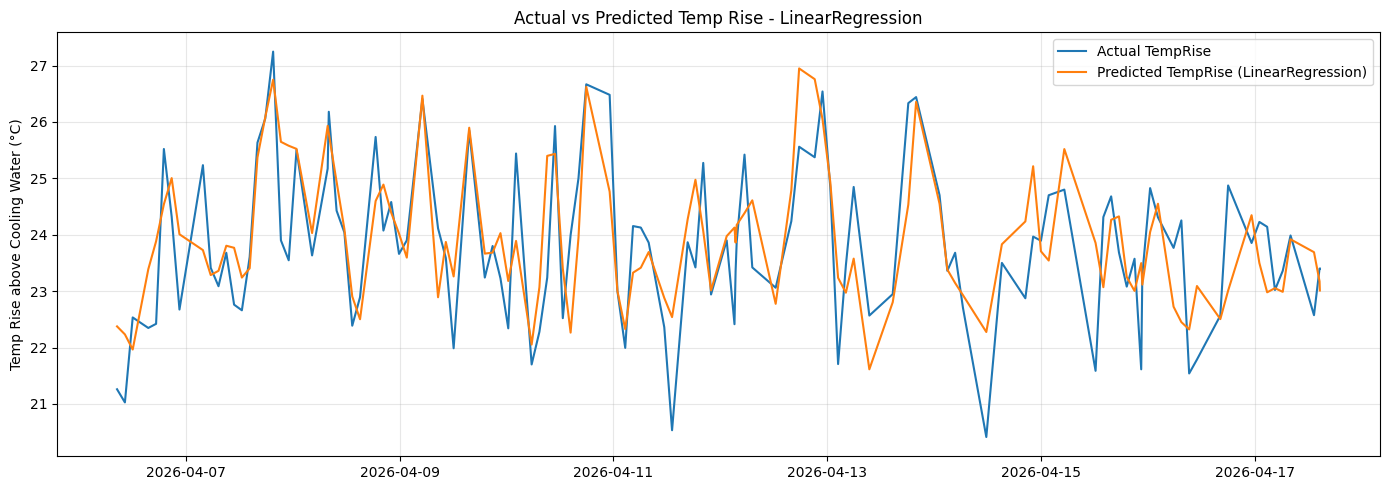

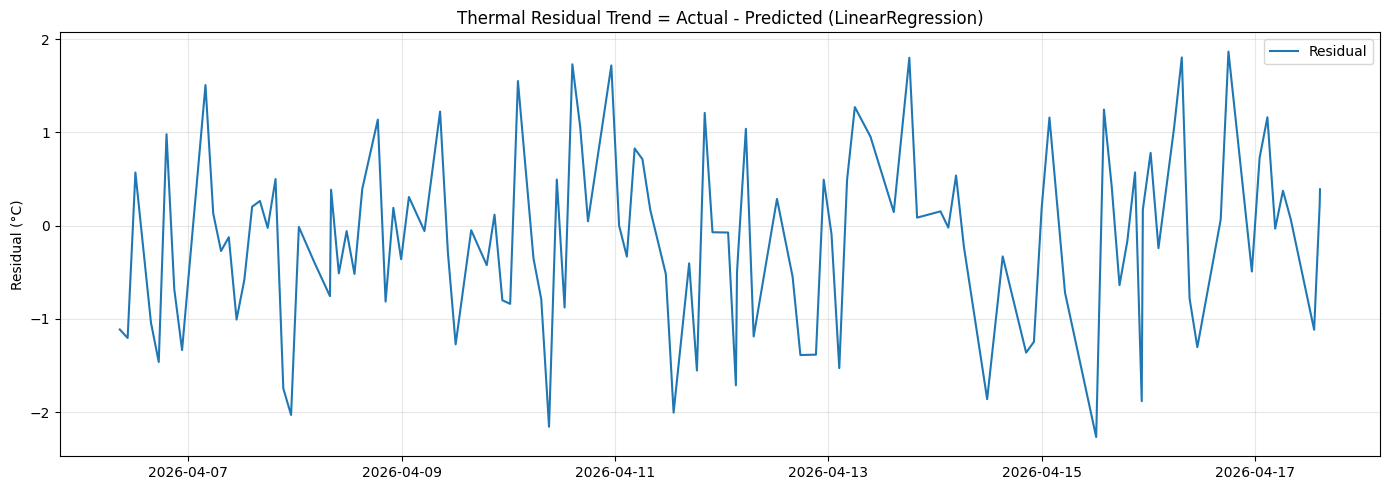

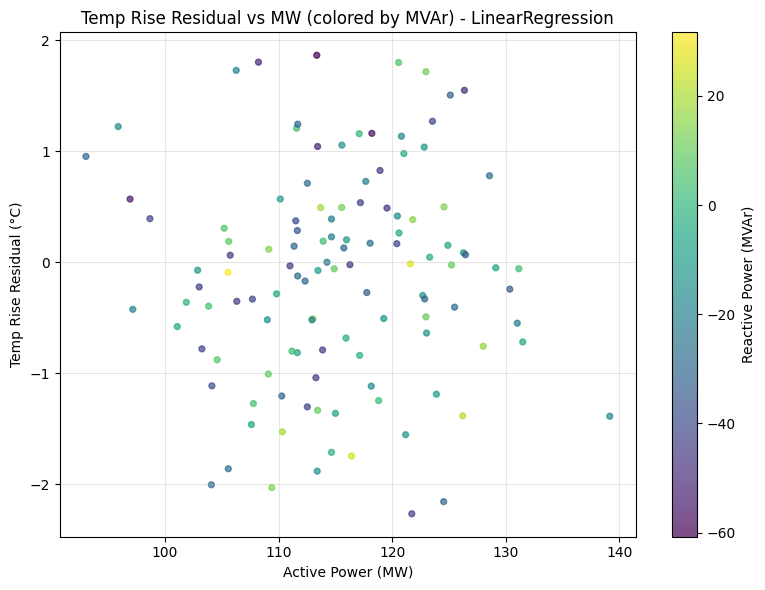

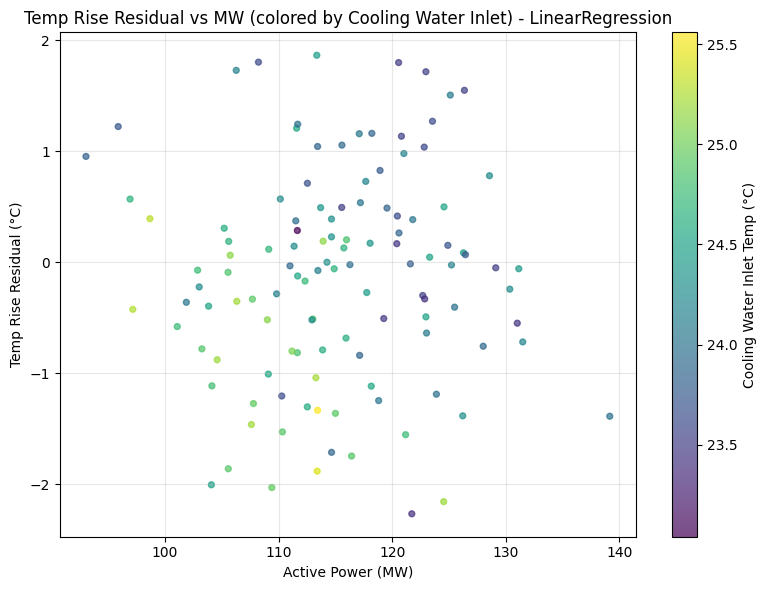

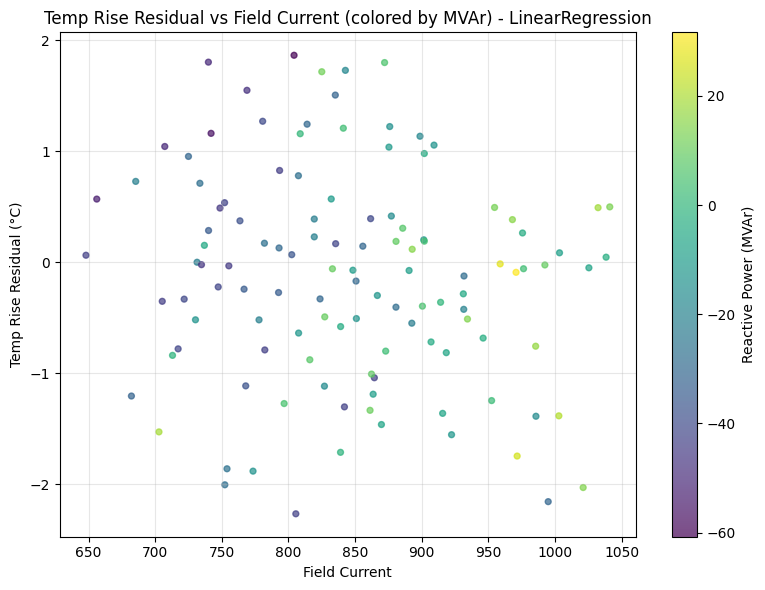


Residual alarm threshold (95% abs): 1.862 °C
Residual alarm events: 6

===== QUICK RESULTS =====
Date range: 2026-02-05 14:40:00 to 2026-04-17 14:40:00
Average MW: 109.66
Average MVAr: -19.07
Average |MVAr|: 24.77
Average PF: 0.9653
Average winding temp: 43.47 °C
Average temp rise: 23.0 °C
Max temp rise: 32.56 °C
Average I^2 proxy: 21090921.33
High MVAr threshold: 53.61
Field current high threshold: 954.52

Best model: LinearRegression

Files saved in folder: /content/generator_analysis_outputs_dynamic

Done.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Optional XGBoost
try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

# =========================================================
# 1. FILE PATHS
# =========================================================
electrical_file = r"u3_electrical_data_17_4_2026_R2.csv"
temp_file        = r"u3_winding_temp_17_4_2026_R2.csv"

output_dir = Path("generator_analysis_outputs_dynamic")
output_dir.mkdir(exist_ok=True)

# =========================================================
# 2. READ FILES
# =========================================================
elec = pd.read_csv(electrical_file, encoding="utf-8", sep=",")
temp = pd.read_csv(temp_file, encoding="utf-8", sep=",")

elec.columns = elec.columns.str.strip()
temp.columns = temp.columns.str.strip()

print("Electrical columns:")
print(elec.columns.tolist())
print("\nTemperature columns:")
print(temp.columns.tolist())

# =========================================================
# 3. PARSE TIMESTAMP
# =========================================================
elec["Timestamp"] = pd.to_datetime(elec["Timestamp"], errors="coerce")
temp["Timestamp"] = pd.to_datetime(temp["Timestamp"], errors="coerce")

elec = elec.dropna(subset=["Timestamp"]).copy()
temp = temp.dropna(subset=["Timestamp"]).copy()

elec = elec.sort_values("Timestamp").reset_index(drop=True)
temp = temp.sort_values("Timestamp").reset_index(drop=True)

# =========================================================
# 4. MERGE DATASETS
# =========================================================
df = pd.merge_asof(
    elec,
    temp,
    on="Timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("10min")
)

print("\nMerged shape:", df.shape)

# =========================================================
# 5. RENAME COLUMNS
# =========================================================
rename_map = {
    "Active_power(MW)": "MW",
    "Reactive_power(Mvar)": "MVAr",
    "UNIT Voltage_AB(kV)": "V_AB_kV",
    "UNIT Voltage_BC(kV)": "V_BC_kV",
    "UNIT Voltage_CA(kV)": "V_CA_kV",
    "UNIT CURRENT PHASE A": "I_A",
    "UNIT CURRENT PHASE C": "I_C",
    "UNIT CURRENT PHASE B": "I_B",
    "FIELD CURRENT": "Field_Current",
    "FIELD VOLTAGE": "Field_Voltage",

    "STATOR WINDING PHASE U2 TEMP": "Winding_U2_Temp",
    "STATOR WINDING PHASE U164 TEMP": "Winding_U164_Temp",

    "GENERATOR COOLING WATER INLET TEMP": "Cooling_Water_Inlet_Temp",
    "GENERATOR COOLING WATER OUTLET TEMP": "Cooling_Water_Outlet_Temp",
    "UPPER BEARING OIL COOLER WARM WATER": "Upper_Bearing_Warm_Water",
    "LOWER BEARING OIL COOLER WARM WATER": "Lower_Bearing_Warm_Water",
    "COLD AIR TEMP": "Cold_Air_Temp",
    "HOT AIR TEMP": "Hot_Air_Temp",
}
df = df.rename(columns=rename_map)

# =========================================================
# 6. CHECK REQUIRED COLUMNS
# =========================================================
required_cols = [
    "Timestamp", "MW", "MVAr",
    "I_A", "I_B", "I_C",
    "V_AB_kV", "V_BC_kV", "V_CA_kV",
    "Field_Current", "Field_Voltage",
    "Winding_U2_Temp", "Winding_U164_Temp",
    "Cooling_Water_Inlet_Temp"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# =========================================================
# 7. BASIC CLEANING
# =========================================================
numeric_cols = [c for c in df.columns if c != "Timestamp"]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=[
    "MW", "MVAr",
    "I_A", "I_B", "I_C",
    "V_AB_kV", "V_BC_kV", "V_CA_kV",
    "Field_Current",
    "Winding_U2_Temp", "Winding_U164_Temp",
    "Cooling_Water_Inlet_Temp"
]).copy()

# =========================================================
# 8. WINDING SENSOR LIST
# =========================================================
winding_temp_cols = [
    "Winding_U2_Temp",
    "Winding_U164_Temp"
]

# =========================================================
# 9. DERIVED ELECTRICAL FEATURES
# =========================================================
df["V_mean_kV"] = df[["V_AB_kV", "V_BC_kV", "V_CA_kV"]].mean(axis=1)
df["I_mean"] = df[["I_A", "I_B", "I_C"]].mean(axis=1)

df["I_imbalance_std_pct"] = np.where(
    df["I_mean"] != 0,
    np.maximum.reduce([
        (df["I_A"] - df["I_mean"]).abs(),
        (df["I_B"] - df["I_mean"]).abs(),
        (df["I_C"] - df["I_mean"]).abs()
    ]) / df["I_mean"] * 100,
    np.nan
)

df["I_max"] = df[["I_A", "I_B", "I_C"]].max(axis=1)
df["I_min"] = df[["I_A", "I_B", "I_C"]].min(axis=1)
df["I_imbalance_fast_pct"] = np.where(
    df["I_mean"] != 0,
    (df["I_max"] - df["I_min"]) / df["I_mean"] * 100,
    np.nan
)

df["MVA"] = np.sqrt(df["MW"]**2 + df["MVAr"]**2)
df["PF_abs"] = np.where(df["MVA"] != 0, np.abs(df["MW"]) / df["MVA"], np.nan)

df["I_per_MW"] = np.where(df["MW"] != 0, df["I_mean"] / df["MW"], np.nan)
df["FieldCurrent_per_MW"] = np.where(df["MW"] != 0, df["Field_Current"] / df["MW"], np.nan)

# I^2R / copper-loss proxies
df["I_mean_sq"] = df["I_mean"] ** 2
df["Copper_loss_proxy"] = df["I_A"]**2 + df["I_B"]**2 + df["I_C"]**2
df["I2R_proxy"] = df["I_mean_sq"]   # R assumed approximately constant

# Additional nonlinear / interaction features
df["MVAr_abs"] = df["MVAr"].abs()
df["PF_dev"] = 1 - df["PF_abs"]
df["MW_x_MVAr"] = df["MW"] * df["MVAr_abs"]
df["I2_x_Field"] = df["I_mean_sq"] * df["Field_Current"]
df["MW_sq"] = df["MW"] ** 2
df["Field_Current_sq"] = df["Field_Current"] ** 2

# =========================================================
# 10. THERMAL METRICS
# =========================================================
df["Winding_Temp_mean"] = df[winding_temp_cols].mean(axis=1)
df["Winding_Temp_max"] = df[winding_temp_cols].max(axis=1)
df["Winding_Temp_min"] = df[winding_temp_cols].min(axis=1)

df["Winding_Temp_spread"] = df["Winding_Temp_max"] - df["Winding_Temp_min"]
df["Winding_Temp_std"] = df[winding_temp_cols].std(axis=1)
df["Winding_Temp_mad"] = (
    df[winding_temp_cols]
    .sub(df["Winding_Temp_mean"], axis=0)
    .abs()
    .mean(axis=1)
)

temp_dev_abs = df[winding_temp_cols].sub(df["Winding_Temp_mean"], axis=0).abs()
df["Num_temp_outliers_0p5C"] = (temp_dev_abs > 0.5).sum(axis=1)
df["Num_temp_outliers_1p0C"] = (temp_dev_abs > 1.0).sum(axis=1)
df["Worst_sensor_dev"] = temp_dev_abs.max(axis=1)
df["Worst_sensor_name"] = temp_dev_abs.idxmax(axis=1)

df["Winding_U2_minus_U164"] = df["Winding_U2_Temp"] - df["Winding_U164_Temp"]
df["Winding_abs_diff_U2_U164"] = df["Winding_U2_minus_U164"].abs()

# Use TempRise as target
df["TempRise_mean_vs_CoolingWater"] = df["Winding_Temp_mean"] - df["Cooling_Water_Inlet_Temp"]
df["TempRise_max_vs_CoolingWater"] = df["Winding_Temp_max"] - df["Cooling_Water_Inlet_Temp"]

if "Cooling_Water_Outlet_Temp" in df.columns:
    df["Cooling_Water_DeltaT"] = df["Cooling_Water_Outlet_Temp"] - df["Cooling_Water_Inlet_Temp"]

if "Hot_Air_Temp" in df.columns and "Cold_Air_Temp" in df.columns:
    df["Air_DeltaT"] = df["Hot_Air_Temp"] - df["Cold_Air_Temp"]

# =========================================================
# 11. OPTIONAL OPERATION FILTER
# =========================================================
df["MW_diff_abs"] = df["MW"].diff().abs()

steady_df = df[
    (df["MW"] > 20) &
    (df["MW_diff_abs"].fillna(0) < 15)
].copy()

print("\nRows before steady filter:", len(df))
print("Rows after steady filter :", len(steady_df))

analysis_df = steady_df.copy()

# =========================================================
# 12. DEFINE HIGH MVAR ZONE / OVER-EXCITATION
# =========================================================
# You can tune these thresholds later with your unit data
analysis_df["High_MVAr_Zone"] = analysis_df["MVAr_abs"] > analysis_df["MVAr_abs"].quantile(0.90)

# Sign convention may differ by plant.
# If your plant considers positive MVAr = over-excited, use > 0
# If negative MVAr = over-excited, change to < 0
OVER_EXCITED_SIGN = "auto"   # "positive", "negative", or "auto"

if OVER_EXCITED_SIGN == "positive":
    over_excitation_side = analysis_df["MVAr"] > 0
elif OVER_EXCITED_SIGN == "negative":
    over_excitation_side = analysis_df["MVAr"] < 0
else:
    # Auto: whichever side is more associated with higher field current
    fc_pos = analysis_df.loc[analysis_df["MVAr"] > 0, "Field_Current"].median()
    fc_neg = analysis_df.loc[analysis_df["MVAr"] < 0, "Field_Current"].median()
    if pd.notna(fc_pos) and pd.notna(fc_neg) and fc_pos >= fc_neg:
        over_excitation_side = analysis_df["MVAr"] > 0
    else:
        over_excitation_side = analysis_df["MVAr"] < 0

field_high_thr = analysis_df["Field_Current"].quantile(0.90)
analysis_df["Over_Excitation_Flag"] = (
    (analysis_df["Field_Current"] > field_high_thr) &
    over_excitation_side
)

# =========================================================
# 13. ADD THERMAL INERTIA FEATURES
# =========================================================
# Sort by time before lags
analysis_df = analysis_df.sort_values("Timestamp").reset_index(drop=True)

# Target lags
for lag in [1, 2, 3, 6]:
    analysis_df[f"TempRise_lag{lag}"] = analysis_df["TempRise_mean_vs_CoolingWater"].shift(lag)

# Operating state lags
for lag in [1, 2, 3]:
    analysis_df[f"MW_lag{lag}"] = analysis_df["MW"].shift(lag)
    analysis_df[f"MVAr_lag{lag}"] = analysis_df["MVAr"].shift(lag)
    analysis_df[f"Field_Current_lag{lag}"] = analysis_df["Field_Current"].shift(lag)
    analysis_df[f"I_mean_lag{lag}"] = analysis_df["I_mean"].shift(lag)

# Smoothed memory term
analysis_df["TempRise_ewm"] = analysis_df["TempRise_mean_vs_CoolingWater"].ewm(span=10, adjust=False).mean().shift(1)

# Ramping / dynamic change terms
analysis_df["dMW"] = analysis_df["MW"].diff()
analysis_df["dMVAr"] = analysis_df["MVAr"].diff()
analysis_df["dField_Current"] = analysis_df["Field_Current"].diff()
analysis_df["dI_mean"] = analysis_df["I_mean"].diff()

# =========================================================
# 14. PLOT FUNCTIONS
# =========================================================
def save_scatter(x, y, xlabel, ylabel, title, filename):
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, s=14, alpha=0.65)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

def save_scatter_colored(df_, x, y, c, xlabel, ylabel, clabel, title, filename):
    plot_df = df_[[x, y, c]].dropna().copy()
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        plot_df[x],
        plot_df[y],
        c=plot_df[c],
        s=18,
        alpha=0.7,
        cmap="viridis"
    )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    cb = plt.colorbar(sc)
    cb.set_label(clabel)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

def save_time_trend(df_, y_cols, labels, ylabel, title, filename):
    plt.figure(figsize=(14, 5))
    for col, label in zip(y_cols, labels):
        plt.plot(df_["Timestamp"], df_[col], label=label)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

# =========================================================
# 15. BASIC PLOTS
# =========================================================
save_time_trend(
    analysis_df,
    ["MW"],
    ["MW"],
    "MW",
    "Active Power Trend",
    "01_MW_trend.png"
)

save_time_trend(
    analysis_df,
    ["Winding_U2_Temp", "Winding_U164_Temp", "Cooling_Water_Inlet_Temp"],
    ["Winding U2 Temp", "Winding U164 Temp", "Cooling Water Inlet Temp"],
    "Temperature (°C)",
    "Winding and Cooling Water Temperatures",
    "02_temperature_trend.png"
)

save_scatter(
    analysis_df["MW"], analysis_df["TempRise_mean_vs_CoolingWater"],
    "Active Power (MW)", "Temp Rise above Cooling Water (°C)",
    "Temperature Rise vs Active Power",
    "03_temp_rise_vs_MW.png"
)

save_scatter(
    analysis_df["I_mean_sq"], analysis_df["TempRise_mean_vs_CoolingWater"],
    "I_mean^2", "Temp Rise above Cooling Water (°C)",
    "Temp Rise vs I^2 (I^2R proxy)",
    "04_temprise_vs_I2.png"
)

save_scatter(
    analysis_df["Field_Current"], analysis_df["TempRise_mean_vs_CoolingWater"],
    "Field Current", "Temp Rise above Cooling Water (°C)",
    "Temp Rise vs Field Current",
    "05_temprise_vs_fieldcurrent.png"
)

save_scatter_colored(
    analysis_df,
    x="MW",
    y="TempRise_mean_vs_CoolingWater",
    c="MVAr",
    xlabel="Active Power (MW)",
    ylabel="Temp Rise above Cooling Water (°C)",
    clabel="Reactive Power (MVAr)",
    title="Temp Rise vs MW (colored by MVAr)",
    filename="06_temprise_vs_MW_colored_by_MVAr.png"
)

save_scatter_colored(
    analysis_df,
    x="MW",
    y="TempRise_mean_vs_CoolingWater",
    c="Cooling_Water_Inlet_Temp",
    xlabel="Active Power (MW)",
    ylabel="Temp Rise above Cooling Water (°C)",
    clabel="Cooling Water Inlet Temp (°C)",
    title="Temp Rise vs MW (colored by Cooling Water Inlet)",
    filename="07_temprise_vs_MW_colored_by_CW.png"
)

# =========================================================
# 16. DYNAMIC MODEL DATASET
# =========================================================
dynamic_features = [
    # electrical / thermal drivers
    "MW",
    "MVAr",
    "MVAr_abs",
    "I_mean",
    "I_mean_sq",
    "Copper_loss_proxy",
    "I2R_proxy",
    "V_mean_kV",
    "Field_Current",
    "Field_Current_sq",
    "Cooling_Water_Inlet_Temp",
    "PF_abs",
    "PF_dev",

    # nonlinear interactions
    "MW_x_MVAr",
    "I2_x_Field",
    "I_per_MW",
    "FieldCurrent_per_MW",

    # dynamic / inertia
    "TempRise_lag1",
    "TempRise_lag2",
    "TempRise_lag3",
    "TempRise_lag6",
    "TempRise_ewm",
    "MW_lag1",
    "MW_lag2",
    "MW_lag3",
    "MVAr_lag1",
    "MVAr_lag2",
    "MVAr_lag3",
    "Field_Current_lag1",
    "Field_Current_lag2",
    "Field_Current_lag3",
    "I_mean_lag1",
    "I_mean_lag2",
    "I_mean_lag3",
    "dMW",
    "dMVAr",
    "dField_Current",
    "dI_mean",

    # flags as features
    "High_MVAr_Zone",
    "Over_Excitation_Flag"
]

target_col = "TempRise_mean_vs_CoolingWater"

model_df = analysis_df.dropna(subset=dynamic_features + [target_col]).copy()

# Convert bools to int
for col in ["High_MVAr_Zone", "Over_Excitation_Flag"]:
    model_df[col] = model_df[col].astype(int)

X = model_df[dynamic_features]
y = model_df[target_col]

# Time split is better than random split for dynamic systems
split_idx = int(len(model_df) * 0.80)
train_df = model_df.iloc[:split_idx].copy()
test_df  = model_df.iloc[split_idx:].copy()

X_train = train_df[dynamic_features]
y_train = train_df[target_col]
X_test  = test_df[dynamic_features]
y_test  = test_df[target_col]

# =========================================================
# 17. MODELS
# =========================================================
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
}

if XGB_AVAILABLE:
    models["XGBoost"] = XGBRegressor(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        objective="reg:squarederror"
    )

metrics_rows = []
pred_cols = []

for name, model in models.items():
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    metrics_rows.append({
        "Model": name,
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Train_MAE_C": train_mae,
        "Test_MAE_C": test_mae,
        "Train_RMSE_C": train_rmse,
        "Test_RMSE_C": test_rmse
    })

    test_df[f"{name}_pred"] = test_pred
    test_df[f"{name}_residual"] = y_test - test_pred
    pred_cols.append(f"{name}_pred")

metrics_df = pd.DataFrame(metrics_rows).sort_values("Test_R2", ascending=False)
metrics_df.to_csv(output_dir / "dynamic_model_metrics.csv", index=False)

print("\n===== DYNAMIC MODEL PERFORMANCE =====")
print(metrics_df.round(4))

best_model_name = metrics_df.iloc[0]["Model"]
best_pred_col = f"{best_model_name}_pred"
best_res_col = f"{best_model_name}_residual"

print(f"\nBest model selected: {best_model_name}")

# =========================================================
# 18. FEATURE IMPORTANCE
# =========================================================
if best_model_name == "LinearRegression":
    best_model = models["LinearRegression"]
    feature_importance_df = pd.DataFrame({
        "Feature": dynamic_features,
        "Importance": best_model.coef_
    }).sort_values("Importance", key=np.abs, ascending=False)
else:
    best_model = models[best_model_name]
    feature_importance_df = pd.DataFrame({
        "Feature": dynamic_features,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)

feature_importance_df.to_csv(output_dir / "best_model_feature_importance.csv", index=False)

# =========================================================
# 19. PREDICTION / RESIDUAL PLOTS
# =========================================================
save_time_trend(
    test_df,
    [target_col, best_pred_col],
    ["Actual TempRise", f"Predicted TempRise ({best_model_name})"],
    "Temp Rise above Cooling Water (°C)",
    f"Actual vs Predicted Temp Rise - {best_model_name}",
    "08_actual_vs_predicted_temprise.png"
)

save_time_trend(
    test_df,
    [best_res_col],
    ["Residual"],
    "Residual (°C)",
    f"Thermal Residual Trend = Actual - Predicted ({best_model_name})",
    "09_temprise_residual_trend.png"
)

save_scatter_colored(
    test_df,
    x="MW",
    y=best_res_col,
    c="MVAr",
    xlabel="Active Power (MW)",
    ylabel="Temp Rise Residual (°C)",
    clabel="Reactive Power (MVAr)",
    title=f"Temp Rise Residual vs MW (colored by MVAr) - {best_model_name}",
    filename="10_temprise_residual_vs_MW_colored_by_MVAr.png"
)

save_scatter_colored(
    test_df,
    x="MW",
    y=best_res_col,
    c="Cooling_Water_Inlet_Temp",
    xlabel="Active Power (MW)",
    ylabel="Temp Rise Residual (°C)",
    clabel="Cooling Water Inlet Temp (°C)",
    title=f"Temp Rise Residual vs MW (colored by Cooling Water Inlet) - {best_model_name}",
    filename="11_temprise_residual_vs_MW_colored_by_CW.png"
)

save_scatter_colored(
    test_df,
    x="Field_Current",
    y=best_res_col,
    c="MVAr",
    xlabel="Field Current",
    ylabel="Temp Rise Residual (°C)",
    clabel="Reactive Power (MVAr)",
    title=f"Temp Rise Residual vs Field Current (colored by MVAr) - {best_model_name}",
    filename="12_temprise_residual_vs_fieldcurrent_colored_by_MVAr.png"
)

# =========================================================
# 20. RESIDUAL ALARMS
# =========================================================
res_thr = test_df[best_res_col].abs().quantile(0.95)
test_df["Residual_Alarm"] = test_df[best_res_col].abs() > res_thr
residual_events = test_df[test_df["Residual_Alarm"]].copy()
residual_events.to_csv(output_dir / "residual_alarm_events.csv", index=False)

print("\nResidual alarm threshold (95% abs):", round(res_thr, 3), "°C")
print("Residual alarm events:", len(residual_events))

# =========================================================
# 21. HEALTH FLAGS
# =========================================================
analysis_df["High_TempSpread_Flag"] = analysis_df["Winding_Temp_spread"] > 2.0
analysis_df["High_TempStd_Flag"] = analysis_df["Winding_Temp_std"] > 1.0
analysis_df["High_TempMAD_Flag"] = analysis_df["Winding_Temp_mad"] > 0.7
analysis_df["High_TwoPointDiff_Flag"] = analysis_df["Winding_abs_diff_U2_U164"] > 2.0

analysis_df["High_IimbalanceStd_Flag"] = analysis_df["I_imbalance_std_pct"] > 5.0
analysis_df["High_IimbalanceFast_Flag"] = analysis_df["I_imbalance_fast_pct"] > 8.0

analysis_df["Low_PF_Flag"] = analysis_df["PF_abs"] < 0.90
analysis_df["High_TempRise_Flag"] = (
    analysis_df["TempRise_mean_vs_CoolingWater"]
    > analysis_df["TempRise_mean_vs_CoolingWater"].quantile(0.95)
)

analysis_df["High_MVAr_Zone_Flag"] = analysis_df["High_MVAr_Zone"]
analysis_df["Over_Excitation_Flag_Final"] = analysis_df["Over_Excitation_Flag"]

health_summary = pd.DataFrame({
    "Metric": [
        "Rows_analyzed",
        "High_TempSpread_rows",
        "High_TempStd_rows",
        "High_TempMAD_rows",
        "High_TwoPointDiff_rows",
        "High_IimbalanceStd_rows",
        "High_IimbalanceFast_rows",
        "Low_PF_rows",
        "High_TempRise_rows",
        "High_MVAr_Zone_rows",
        "Over_Excitation_rows"
    ],
    "Value": [
        len(analysis_df),
        analysis_df["High_TempSpread_Flag"].sum(),
        analysis_df["High_TempStd_Flag"].sum(),
        analysis_df["High_TempMAD_Flag"].sum(),
        analysis_df["High_TwoPointDiff_Flag"].sum(),
        analysis_df["High_IimbalanceStd_Flag"].sum(),
        analysis_df["High_IimbalanceFast_Flag"].sum(),
        analysis_df["Low_PF_Flag"].sum(),
        analysis_df["High_TempRise_Flag"].sum(),
        analysis_df["High_MVAr_Zone_Flag"].sum(),
        analysis_df["Over_Excitation_Flag_Final"].sum()
    ]
})

health_summary.to_csv(output_dir / "health_flag_summary.csv", index=False)

# =========================================================
# 22. DAILY SUMMARY
# =========================================================
analysis_df["Date"] = analysis_df["Timestamp"].dt.date

daily_summary = analysis_df.groupby("Date").agg(
    MW_mean=("MW", "mean"),
    MW_max=("MW", "max"),
    MVAr_mean=("MVAr", "mean"),
    MVAr_abs_mean=("MVAr_abs", "mean"),
    PF_mean=("PF_abs", "mean"),
    I_mean=("I_mean", "mean"),

    Winding_Temp_mean=("Winding_Temp_mean", "mean"),
    Winding_Temp_max=("Winding_Temp_max", "max"),

    TempRise_mean=("TempRise_mean_vs_CoolingWater", "mean"),
    TempRise_max=("TempRise_mean_vs_CoolingWater", "max"),

    FieldCurrent_mean=("Field_Current", "mean"),
    CoolingWaterInlet_mean=("Cooling_Water_Inlet_Temp", "mean"),

    High_MVAr_Zone_count=("High_MVAr_Zone_Flag", "sum"),
    Over_Excitation_count=("Over_Excitation_Flag_Final", "sum"),
).reset_index()

daily_summary.to_csv(output_dir / "daily_summary.csv", index=False)

# =========================================================
# 23. SAVE FINAL DATASETS
# =========================================================
df.to_csv(output_dir / "merged_full_dataset.csv", index=False)
analysis_df.to_csv(output_dir / "merged_filtered_analysis_dataset.csv", index=False)
model_df.to_csv(output_dir / "dynamic_model_dataset.csv", index=False)
test_df.to_csv(output_dir / "dynamic_test_predictions.csv", index=False)

# =========================================================
# 24. QUICK RESULTS
# =========================================================
print("\n===== QUICK RESULTS =====")
print("Date range:", analysis_df["Timestamp"].min(), "to", analysis_df["Timestamp"].max())
print("Average MW:", round(analysis_df["MW"].mean(), 2))
print("Average MVAr:", round(analysis_df["MVAr"].mean(), 2))
print("Average |MVAr|:", round(analysis_df["MVAr_abs"].mean(), 2))
print("Average PF:", round(analysis_df["PF_abs"].mean(), 4))
print("Average winding temp:", round(analysis_df["Winding_Temp_mean"].mean(), 2), "°C")
print("Average temp rise:", round(analysis_df["TempRise_mean_vs_CoolingWater"].mean(), 2), "°C")
print("Max temp rise:", round(analysis_df["TempRise_mean_vs_CoolingWater"].max(), 2), "°C")
print("Average I^2 proxy:", round(analysis_df["I_mean_sq"].mean(), 2))
print("High MVAr threshold:", round(analysis_df["MVAr_abs"].quantile(0.90), 2))
print("Field current high threshold:", round(field_high_thr, 2))
print("\nBest model:", best_model_name)
print("\nFiles saved in folder:", output_dir.resolve())
print("\nDone.")